# Image Caption Generator

The goal of this project is to build an algorithm that can generate a caption based on an image.

## 1.0 Setup



### Importing the libraries

In [1]:
import string
import os
import sys
import h5py
import numpy as np
import tensorflow as tf
from pickle import dump
from itertools import islice
from tqdm import tqdm_notebook as tqdm
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, BatchNormalization, Concatenate, GlobalAveragePooling2D, Flatten, GlobalAveragePooling1D, Reshape, Lambda
from tensorflow.keras.losses import CategoricalCrossentropy

sys.path.append(os.path.abspath("..")) 
from src import *

tqdm().pandas()

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2025-09-06 14:30:38.515635: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757158238.609883  236786 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757158238.637067  236786 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757158238.740055  236786 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757158238.740103  236786 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757158238.740108  236786 computation_placer.cc:177] computation placer alr

0it [00:00, ?it/s]

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Setting up paths variables

In [2]:
# Paths to the folders and files
TOKEN_PATH = text_data_raw_dir / "Flickr8k.token.txt"
IMG_PATH = img_data_raw_dir
IMG_TEXT_FILES_PATH = text_data_raw_dir / "Flickr_8k.trainImages.txt"

In [3]:
print(f"Path to image tokens: {TOKEN_PATH}")
print(f"Path to images: {IMG_PATH}")
print(f"Path to images text filenames: {IMG_TEXT_FILES_PATH}")

Path to image tokens: /home/mahmoud/Documents/Software/ML/img_caption_generator/data/raw/Flickr8k_text/Flickr8k.token.txt
Path to images: /home/mahmoud/Documents/Software/ML/img_caption_generator/data/raw/Flickr8k_Dataset/Flicker8k_Dataset
Path to images text filenames: /home/mahmoud/Documents/Software/ML/img_caption_generator/data/raw/Flickr8k_text/Flickr_8k.trainImages.txt


### Helper Functions

In [4]:
# Create function to load the files
def load_file(filename:str):
    """
    load_file: takes a filename and loads its contents into a string

    args: 
        filename (string): path of the file that will be loaded

    returns:
        text (string): a string of all of the lines in the filename
    """

    file = open(filename, 'r')
    text = file.read()
    file.close()
    
    return text

In [5]:
# Create a function to seperate each image with its captions
def img_captions(filename:str):
    """
    img_captions: takes a file of images and all of its captions and creates a dictionary with each image 
                  as the key and the values are all of its  captions

    args:
        filename (string): the name of the file with the images and captions pair

    returns:
        image_descriptions (dictionary): a dictionary with each image as the key and its captions in a list as the value
    """

    # loading the file
    file = load_file(filename)
    captions = file.split("\n")
    image_captions = {}

    for caption in captions[:-1]: # Last line is empty so iterating up to the line before the end
        img, caption = caption.split('\t') # Splitting the image and caption using the 'tab'
        if img[:-2] not in image_captions: # Last 2 in every image has the "#" and "caption number" 
            image_captions[img[:-2]] = [caption]
        else:
            image_captions[img[:-2]].append(caption)

    return image_captions


In [6]:
img_caps = img_captions(TOKEN_PATH)

In [7]:
import pprint
from itertools import islice
pprint.pprint(dict(islice(img_caps.items(), 3)))

{'1000268201_693b08cb0e.jpg': ['A child in a pink dress is climbing up a set '
                               'of stairs in an entry way .',
                               'A girl going into a wooden building .',
                               'A little girl climbing into a wooden playhouse '
                               '.',
                               'A little girl climbing the stairs to her '
                               'playhouse .',
                               'A little girl in a pink dress going into a '
                               'wooden cabin .'],
 '1001773457_577c3a7d70.jpg': ['A black dog and a spotted dog are fighting',
                               'A black dog and a tri-colored dog playing with '
                               'each other on the road .',
                               'A black dog and a white dog with brown spots '
                               'are staring at each other in the street .',
                               'Two dogs of differ

In [8]:
# Create a function to simplify captions
def simplify(captions:dict):
    """
    simplify: takes a dictionary of image and its captions and removes punctuations, numbers, and changes uppercase letters into lowercase.

    args: 
        captions (dictionary): A dictionary of each image as the key and a list of captions as the value.

    returns:
        captions (dictionary): Returns the same dictionary after simplifying the captions 
    """
    
    table = str.maketrans("", "", string.punctuation)
    
    for img, img_captions in captions.items():
        for i, caption in enumerate(img_captions):
            
            caption.replace("-"," ") # Replacing "-" with a blank space
            words = caption.split() # Splitting each word in the dictionary

            words = [word.lower() for word in words] 
            words = [word.translate(table) for word in words] # Applying the translation table of removing the punctuation marks

            words = [word for word in words if len(word)>1] # Only keeping words that are more then 1 character long
            words = [word for word in words if word.isalpha()] # Removing numbers

            caption = " ".join(words)
            captions[img][i] = caption

    return captions

In [9]:
img_caps_simplified = simplify(img_caps)

In [10]:
pprint.pprint(dict(islice(img_caps_simplified.items(), 3)))

{'1000268201_693b08cb0e.jpg': ['child in pink dress is climbing up set of '
                               'stairs in an entry way',
                               'girl going into wooden building',
                               'little girl climbing into wooden playhouse',
                               'little girl climbing the stairs to her '
                               'playhouse',
                               'little girl in pink dress going into wooden '
                               'cabin'],
 '1001773457_577c3a7d70.jpg': ['black dog and spotted dog are fighting',
                               'black dog and tricolored dog playing with each '
                               'other on the road',
                               'black dog and white dog with brown spots are '
                               'staring at each other in the street',
                               'two dogs of different breeds looking at each '
                               'other on the road',
  

In [11]:
# Create a function to make up the vocab used in the text
def make_vocab(captions:dict):
    """
    make_vocab: takes a dictionary of image and its captions and finds all unique words used to make up a set of vocabulary

    args:
        captions (dictionary): A dictionary of each image as the key and a list of captions as the value.

    returns:
        vocab (set): A set of unique words from all the captions
    """

    vocab = set()

    for key in captions.keys():
        
        [vocab.update(c.split()) for c in captions[key]]

    return vocab   

In [12]:
vocab = make_vocab(img_caps_simplified)

In [13]:
len(vocab), list(vocab)[:10]

(8763,
 ['ripped',
  'underneath',
  'tournament',
  'entertains',
  'splashes',
  'snowpile',
  'complex',
  'rockclimber',
  'id',
  'choice'])

In [14]:
# Create a function that saves the images and its new editted captions
def save_captions(captions:dict, filename:str):
    """
    save_captions: takes the new dictionary of image and its new editted captions and saves them 
                   in the original formate of image - caption_number as a text file

    args:
        captions (dictionary): A dictionary of each image as the key and a list of captions as 
                               the value.
        
        filename (string): The filename of the text that will be saved.
    """

    lines = []
    for img, image_captions in captions.items():
        for i, caption in enumerate(image_captions):
            line = img + "\t" + caption
            lines.append(line)

    text ="\n".join(lines)
    
    file = open(filename, "w")
    file.write(text)
    file.close()

In [15]:
save_captions(img_caps_simplified, data_cleaned_dir / "Flickr8k.token_cleaned.txt")

## 2. Building a model for feature extraction

Transfer learning using the Xception model as the base model to extract features
After removing the top layers from the Xception model which is trained on the imagenet dataset in order to extract the feature vector for the images in our dataset 

### Xception base model for feature extraction

In [16]:
# xception_feature_extraction_model = keras.applications.Xception(include_top=False, pooling='average') # Don't want the final layers which output the classification prediction instead we stop at the raw features detected
# features = {}
# for img in tqdm(os.listdir(IMG_PATH)):
#     filename = IMG_PATH / img
#     image = Image.open(filename)
#     image = image.resize((299, 299))
#     image = np.expand_dims(image, axis=0) # changing the shape of the image to (1, 299, 299, 3) as keras expect the input in batches even if batch of 1.
#     image = image / 127.5
#     image = image - 1.0
    
#     feature = xception_feature_extraction_model.predict(image) # outputs the feature vector
#     features[img] = feature
    

In [17]:
# pprint.pprint(dict(islice(features.items(), 1)))

`dump()` function from the pickle module kept crashing the kernel, after testing it seems to be an issue with how large the `features` dictionary is, so had to save the features in a h5 file

In [18]:
# Saving the features vector 
# dump(features, open("../models/features.p","wb"))

In [19]:
# with h5py.File('../models/features.h5', 'w') as f:
#     for k, v in features.items():
#         f.create_dataset(k, data=np.array(v), compression="gzip")


### Loading the images

In [20]:
images = []
with open(IMG_TEXT_FILES_PATH, 'r') as f:
    img_files = f.readlines()
    for file in img_files:
        images.append(file[:-1]) 

In [21]:
len(images), images[0], images[-1]

(6000, '2513260012_03d33305cf.jpg', '2671602981_4edde92658.jpg')

### Loading each image and its captions

In [22]:
with open(data_cleaned_dir / "Flickr8k.token_cleaned.txt", 'r') as captions:
    
    # Load cleaned captions text file
    file = captions.readlines()
    descriptions = {}
    
    file = " ".join(file)

    for line in file.split("\n"):
        words = line.split() # Split each line into words --> ["img001.jpg", "man", "wears", ......]
        
        if len(words)<1:
            continue
        
        image, image_caption = words[0], words[1:]
        
        if image in images:
            # Since each image appears 5 times in the captions text file, we need to initiate it once in the descriptions dict
            # with an empty list and then append to that list each new caption after adding the start and end identifiers
            if image not in descriptions:
                descriptions[image] = []
            desc = "<start> " + " ".join(image_caption) + " <end>"
            descriptions[image].append(desc)

In [23]:
descriptions, len(descriptions)

({'1000268201_693b08cb0e.jpg': ['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
   '<start> girl going into wooden building <end>',
   '<start> little girl climbing into wooden playhouse <end>',
   '<start> little girl climbing the stairs to her playhouse <end>',
   '<start> little girl in pink dress going into wooden cabin <end>'],
  '1001773457_577c3a7d70.jpg': ['<start> black dog and spotted dog are fighting <end>',
   '<start> black dog and tricolored dog playing with each other on the road <end>',
   '<start> black dog and white dog with brown spots are staring at each other in the street <end>',
   '<start> two dogs of different breeds looking at each other on the road <end>',
   '<start> two dogs on pavement moving toward each other <end>'],
  '1002674143_1b742ab4b8.jpg': ['<start> little girl covered in paint sits in front of painted rainbow with her hands in bowl <end>',
   '<start> little girl is sitting in front of large painted rainbow <end

Loading the file was also crashing the kernel so, had to load each vector iteratively.

In [24]:
features = {}
with h5py.File('../models/features.h5', 'r') as f:
    for i, k in enumerate(f.keys()):
        features[k] = f[k][()]  # Load individual array

In [25]:
pprint.pprint(dict(islice(features.items(), 1)))

{'1000268201_693b08cb0e.jpg': array([[[[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.10360497,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.07289892,
          0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]],

        [[0.        , 0.        , 0.        , ..., 0.01908493,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.37761557,
          0.        , 0.17500734],
         [0.        , 0.        , 0.        , ..., 0.3012458 ,
          0.        , 0.53495836],
         ...,
         [0.        , 0.        , 0.        , ..., 0.     

In [26]:
image_feature_vectors = {img:np.mean(features[img][0], axis=(0, 1)) for img in images} # Reshaping the vector to (2048,) instead of (1, 10, 10, 2048)

In [27]:
len(features), len(image_feature_vectors)

(8091, 6000)

In [28]:
image_feature_vectors["2513260012_03d33305cf.jpg"].shape

(2048,)

In [29]:
pprint.pprint(dict(islice(image_feature_vectors.items(), 1)))

{'2513260012_03d33305cf.jpg': array([0.        , 0.44787437, 0.        , ..., 0.17718253, 0.00192081,
       0.00869141], dtype=float32)}


## 3.0 Tokenizing the vocabulary

* Step 1: Convert the disctionary of captions in to a list
* Step 2: Create a token for each word

In [30]:
# Convert the captions dict to a list of captions
all_descs = []
for img, captions in descriptions.items():
    [all_descs.append(caption) for caption in captions]

In [31]:
len(all_descs), all_descs[:10]

(30000,
 ['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
  '<start> girl going into wooden building <end>',
  '<start> little girl climbing into wooden playhouse <end>',
  '<start> little girl climbing the stairs to her playhouse <end>',
  '<start> little girl in pink dress going into wooden cabin <end>',
  '<start> black dog and spotted dog are fighting <end>',
  '<start> black dog and tricolored dog playing with each other on the road <end>',
  '<start> black dog and white dog with brown spots are staring at each other in the street <end>',
  '<start> two dogs of different breeds looking at each other on the road <end>',
  '<start> two dogs on pavement moving toward each other <end>'])

In [32]:
# Initiate a tokenizer class
tk = Tokenizer()
tk.fit_on_texts(all_descs)

In [33]:
dump(tk, open("../models/tokenizer.p", 'wb'))

In [34]:
vocab_size = len(tk.word_index) + 1
vocab_size

7577

In [35]:
length_of_caps = [len(caption.split()) for caption in all_descs]
max_caps = max(length_of_caps)
max_caps

34

## 4.0 Preparing the data for the model

The model can't take all 6000 images, each one 2048 feature vector and the captions as input. So the input will be feature vector and the sequence of caption. However the 6000 images will be divided into batches.


In [36]:
descriptions

{'1000268201_693b08cb0e.jpg': ['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
  '<start> girl going into wooden building <end>',
  '<start> little girl climbing into wooden playhouse <end>',
  '<start> little girl climbing the stairs to her playhouse <end>',
  '<start> little girl in pink dress going into wooden cabin <end>'],
 '1001773457_577c3a7d70.jpg': ['<start> black dog and spotted dog are fighting <end>',
  '<start> black dog and tricolored dog playing with each other on the road <end>',
  '<start> black dog and white dog with brown spots are staring at each other in the street <end>',
  '<start> two dogs of different breeds looking at each other on the road <end>',
  '<start> two dogs on pavement moving toward each other <end>'],
 '1002674143_1b742ab4b8.jpg': ['<start> little girl covered in paint sits in front of painted rainbow with her hands in bowl <end>',
  '<start> little girl is sitting in front of large painted rainbow <end>',
  '<star

In [37]:
[a,b],c = next(data_generator(descriptions=descriptions, 
                              features=image_feature_vectors, 
                              tokenizer= tk, 
                              max_length=max_caps, 
                              vocab_size=vocab_size))

In [38]:
a, a.shape, b, b.shape, c, c.shape

(array([[0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        ...,
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817]], dtype=float32),
 (47, 2048),
 array([[ 2,  0,  0, ...,  0,  0,  0],
        [ 2, 42,  0, ...,  0,  0,  0],
        [ 2, 42,  3, ...,  0,  0,  0],
        ...,
        [ 2, 39, 18, ...,  0,  0,  0],
        [ 2, 39, 18, ...,  0,  0,  0],
        [ 2, 39, 18, ...,  0,  0,  0]], dtype=int32),
 (47, 34),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 

## 5.0 Training the model

### Baseline model

I0000 00:00:1757158281.125449  236786 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5051 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  1,939,712 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7577)      │  1,947,289 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,002,649 (19.08 MB)

 Trainable params: 5,002,649 (19.08 MB)

 Non-trainable params: 0 (0.00 B)

None


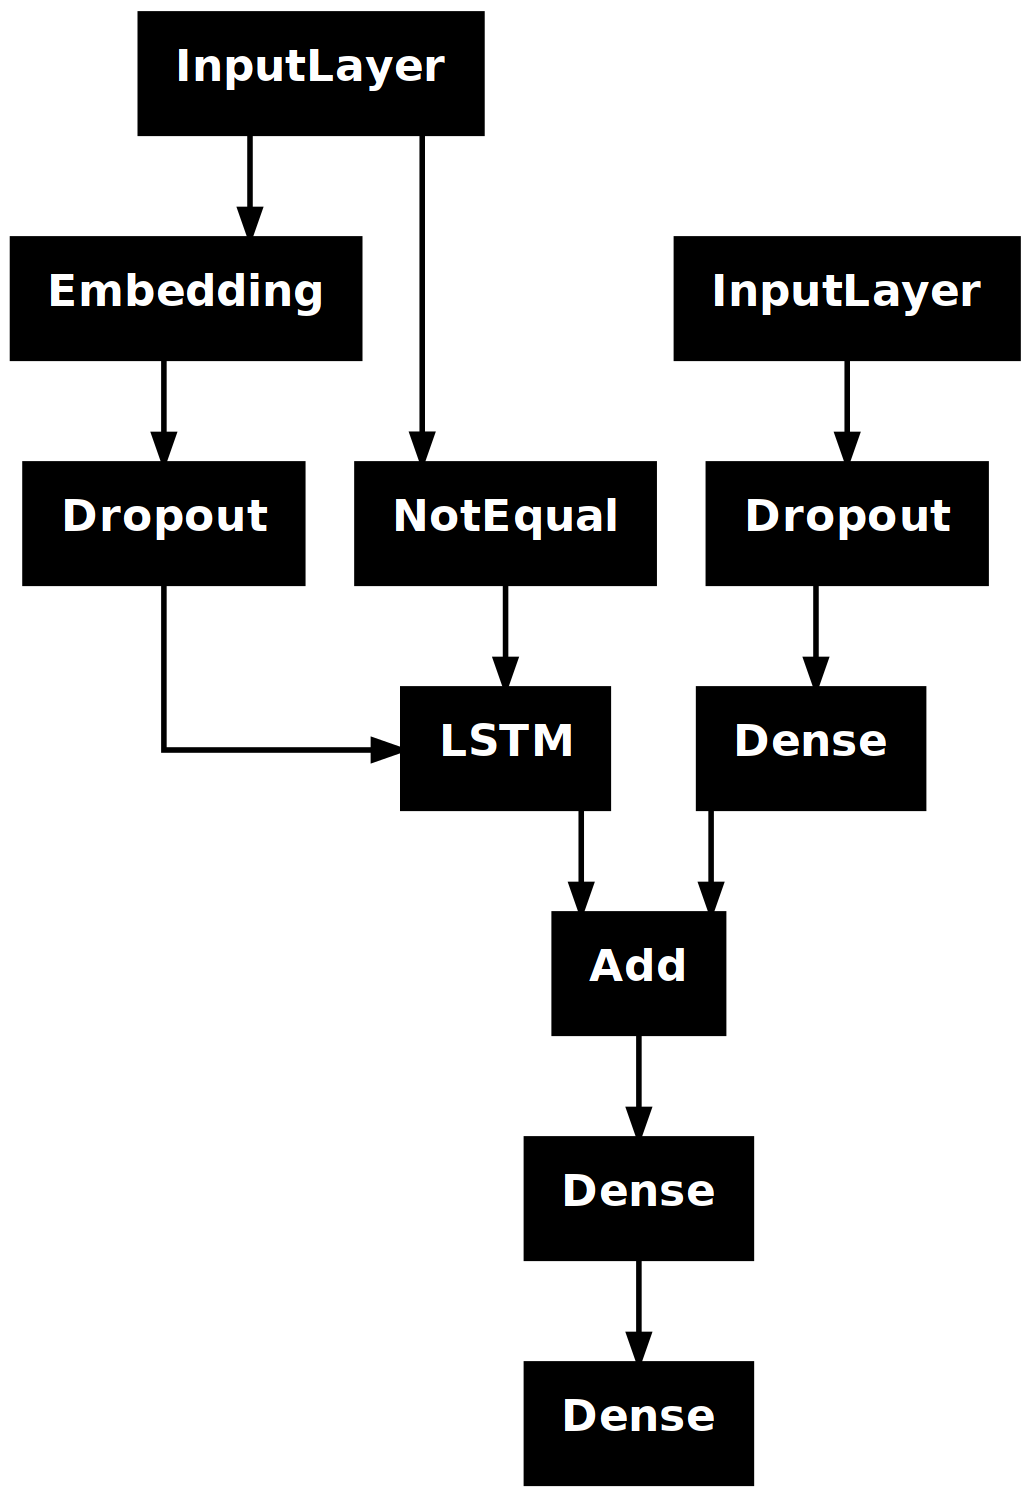

In [39]:
# CNN model inputs
img_inputs = Input(shape=(2048,))
fe1 = Dropout(0.5)(img_inputs)
fe2 = Dense(256)(fe1)

# LSTM model inputs
seq_inputs = Input(shape=(max_caps,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(seq_inputs)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

# Adding the models
decoder1 = Add()([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[img_inputs, seq_inputs], 
              outputs=outputs)
model.compile(loss='categorical_crossentropy',
              optimizer='Adam')

print(model.summary())
plot_model(model, to_file='../models/models_summary/base_line_model.png')

In [40]:
print('Dataset: ', len(images))
print('Descriptions: ', len(descriptions))
print('Photos: ', len(image_feature_vectors))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_caps)

Dataset:  6000
Descriptions:  6000
Photos:  6000
Vocabulary Size: 7577
Description Length:  34


In [41]:
# # Base model training

# EPOCHS = 10
# STEPS = len(descriptions)

# for i in range(EPOCHS):
    
#     history_base = model.fit(data_generator(descriptions=descriptions,
#                                             features=image_feature_vectors,
#                                             tokenizer=tk,
#                                             max_length=max_caps,
#                                             vocab_size=vocab_size),
#                                             epochs=1, 
#                                             steps_per_epoch=STEPS, 
#                                             verbose=1)
    
#     model.save("../models/baseline_model/baseline_model_" + str(i) + ".keras")

I0000 00:00:1757158283.628208  236890 service.cc:152] XLA service 0x198a94b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757158283.628264  236890 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-09-06 14:31:23.665900: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1757158284.010957  236890 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


I0000 00:00:1757158287.383313  236890 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


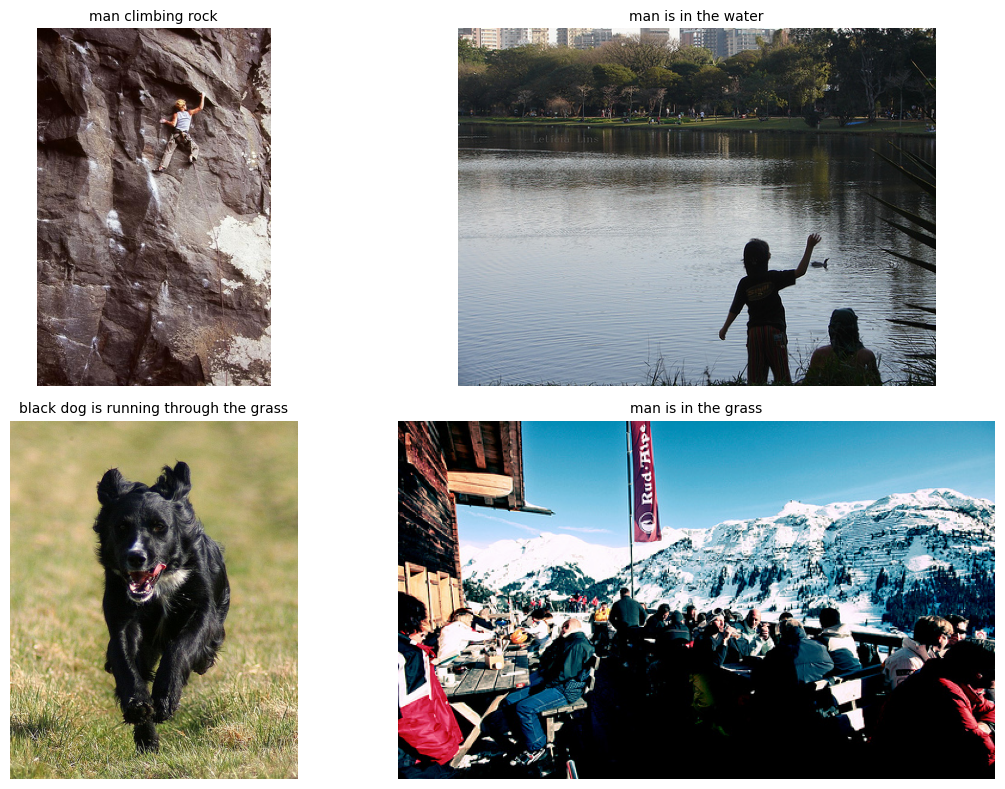

In [42]:
base_model = load_model("../models/baseline_model/baseline_model_7.keras")

test_features = load_testing_imgs(directory="../data/raw/Flickr8k_Dataset/Flicker8k_Dataset",
                             txt_file="../data/raw/Flickr8k_text/Flickr_8k.devImages.txt")

caps = generate_captions_for_images(model=base_model, 
                                    tokenizer=tk, 
                                    features=test_features, 
                                    max_length=max_caps)

display_images_with_captions(
    captions_dict=caps,
    image_dir="../data/raw/testing_images"
)

### Model 1

- Increasing the number of epochs
- Adding another LSTM layer
- Changing `ADD()` to `Concatenate()`

/home/mahmoud/anaconda3/envs/tf_gpu_py311/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │  1,049,088 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 256)   │  1,939,712 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 34)        │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ embedding_1[0][0… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    393,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 7577)      │  1,947,289 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,986,457 (22.84 MB)

 Trainable params: 5,986,457 (22.84 MB)

 Non-trainable params: 0 (0.00 B)

None


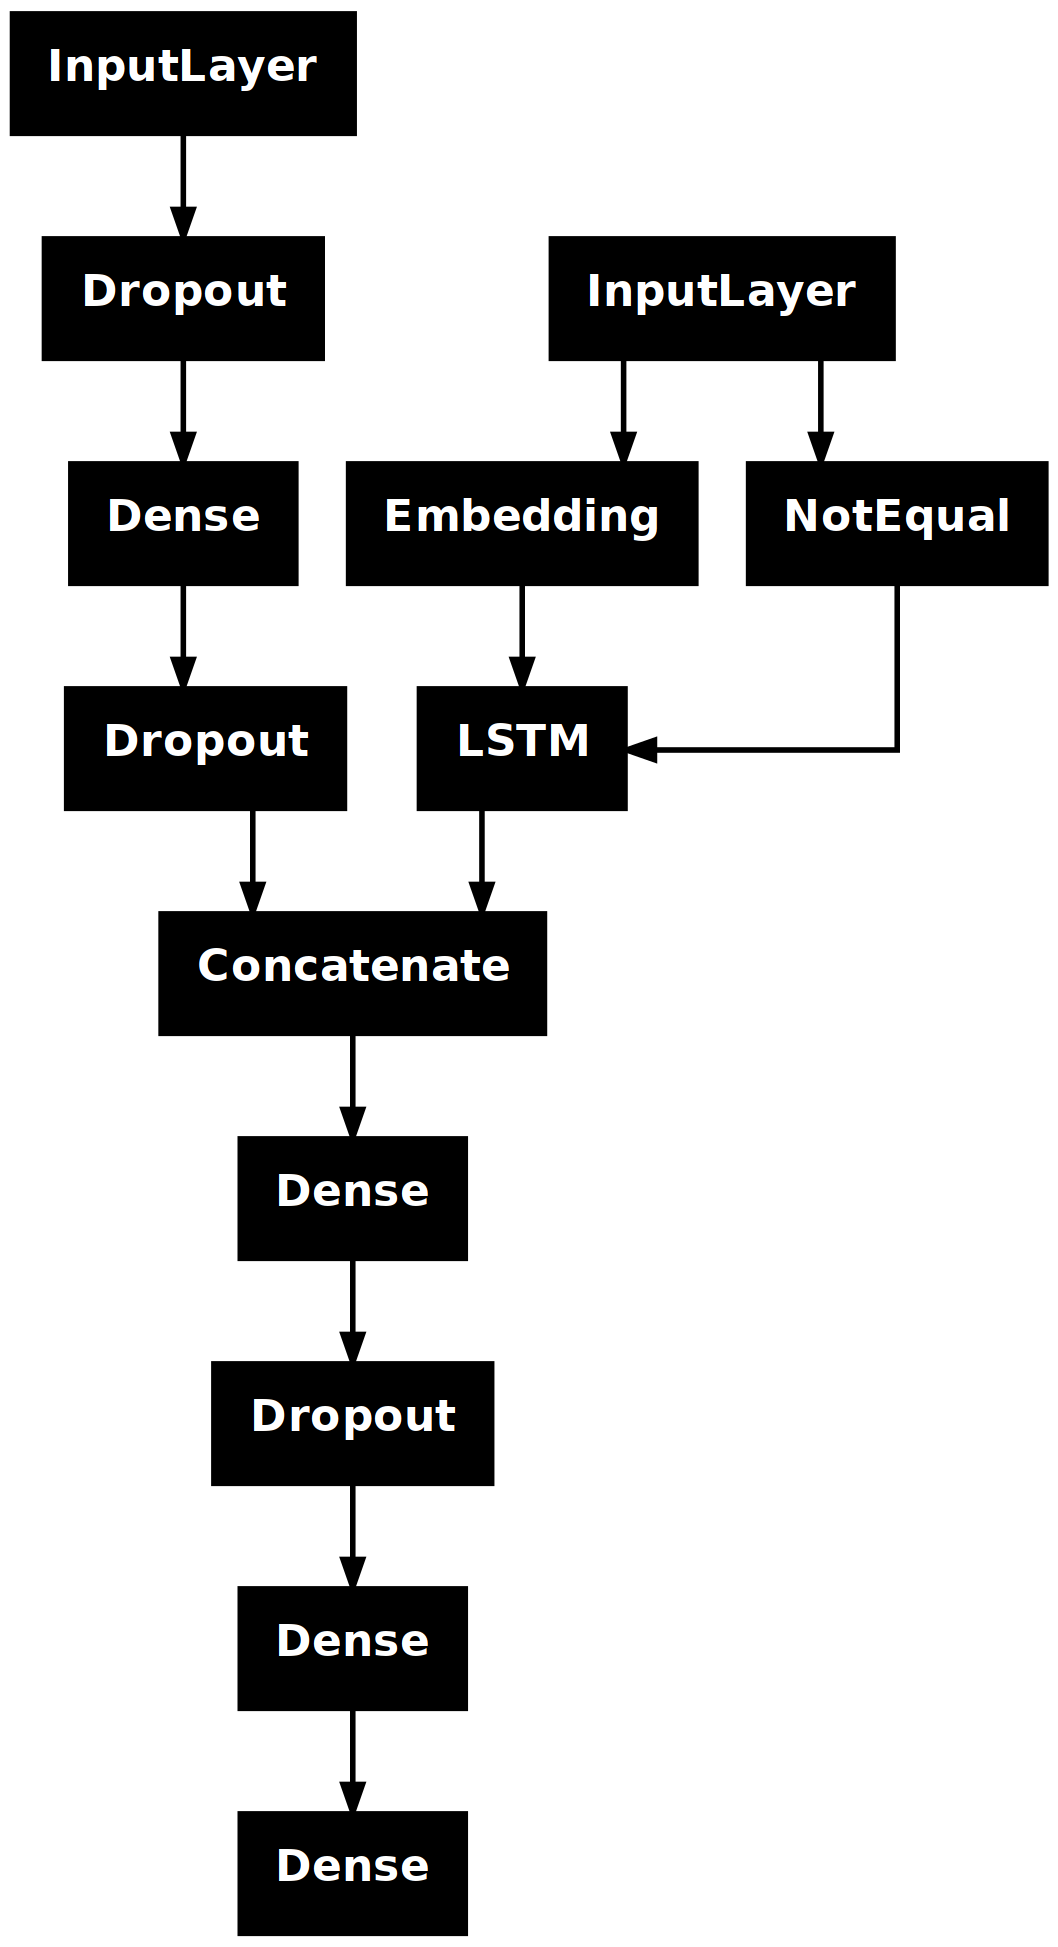

In [43]:
# CNN model inputs
img_inputs = Input(shape=(2048,))
fe1 = Dropout(0.5)(img_inputs)
fe2 = Dense(512, activation='relu')(fe1)
fe3 = Dropout(0.5)(fe2)

# LSTM model inputs
seq_inputs = Input(shape=(max_caps,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(seq_inputs)
se2 = LSTM(256)(se1)

# Adding the models
decoder1 = Concatenate()([fe3, se2])
decoder2 = Dense(512, activation='relu')(decoder1)
decoder2 = Dropout(0.5)(decoder2)
decoder3 = Dense(256, activation='relu')(decoder2)
outputs = Dense(vocab_size, activation='softmax')(decoder3)

model = Model(inputs=[img_inputs, seq_inputs], 
              outputs=outputs)

loss = CategoricalCrossentropy(label_smoothing=0.1)
optimizer = Adam(learning_rate=1e-4, decay=1e-6, clipnorm=5.0)

model.compile(loss=loss,
              optimizer=optimizer)

print(model.summary())
plot_model(model, to_file='../models/models_summary/model_1.png')

In [44]:
# # Model_1 training

# EPOCHS = 10
# STEPS = len(descriptions)


# for i in range(EPOCHS):
    
#     history_1 = model.fit(data_generator(descriptions=descriptions,
#                                          features=image_feature_vectors,
#                                          tokenizer=tk,
#                                          max_length=max_caps,
#                                          vocab_size=vocab_size),
#                                          epochs=1, 
#                                          steps_per_epoch=STEPS, 
#                                          verbose=1)
    
#     model.save("../models/model_1/model_1_" + str(i) + ".keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


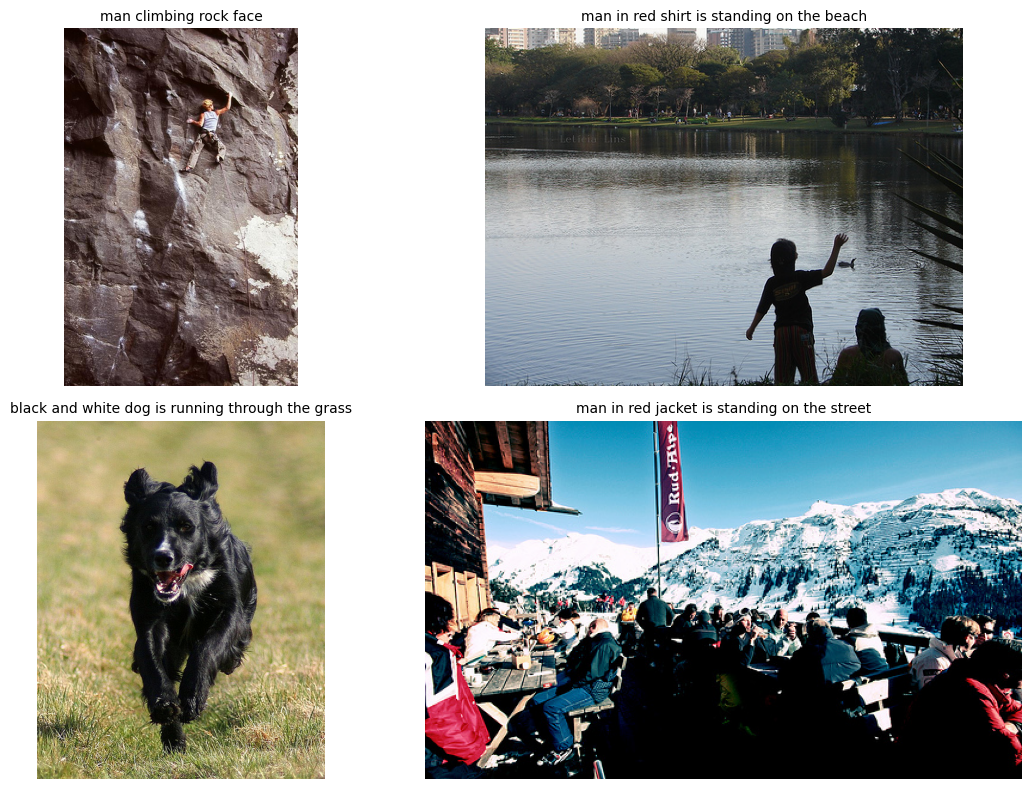

In [45]:
model_1 = load_model("../models/model_1/model_1_9.keras")

test_features = load_testing_imgs(directory="../data/raw/Flickr8k_Dataset/Flicker8k_Dataset",
                             txt_file="../data/raw/Flickr8k_text/Flickr_8k.devImages.txt")

caps = generate_captions_for_images(model=model_1, 
                                    tokenizer=tk, 
                                    features=test_features, 
                                    max_length=max_caps)

display_images_with_captions(
    captions_dict=caps,
    image_dir="../data/raw/testing_images"
)

### Model 2

* Using Model 1 structure
* Increasing the number of epochs
* Generating captions with beam search instead of greedy search

In [46]:
# # Model_2 training

# EPOCHS = 30
# STEPS = len(descriptions)


# for i in range(EPOCHS):
    
#     history_2 = model.fit(data_generator(descriptions=descriptions,
#                                          features=image_feature_vectors,
#                                          tokenizer=tk,
#                                          max_length=max_caps,
#                                          vocab_size=vocab_size),
#                                          epochs=1, 
#                                          steps_per_epoch=STEPS, 
#                                          verbose=1)
    
#     model.save("../models/model_2/model_2_" + str(i) + ".keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


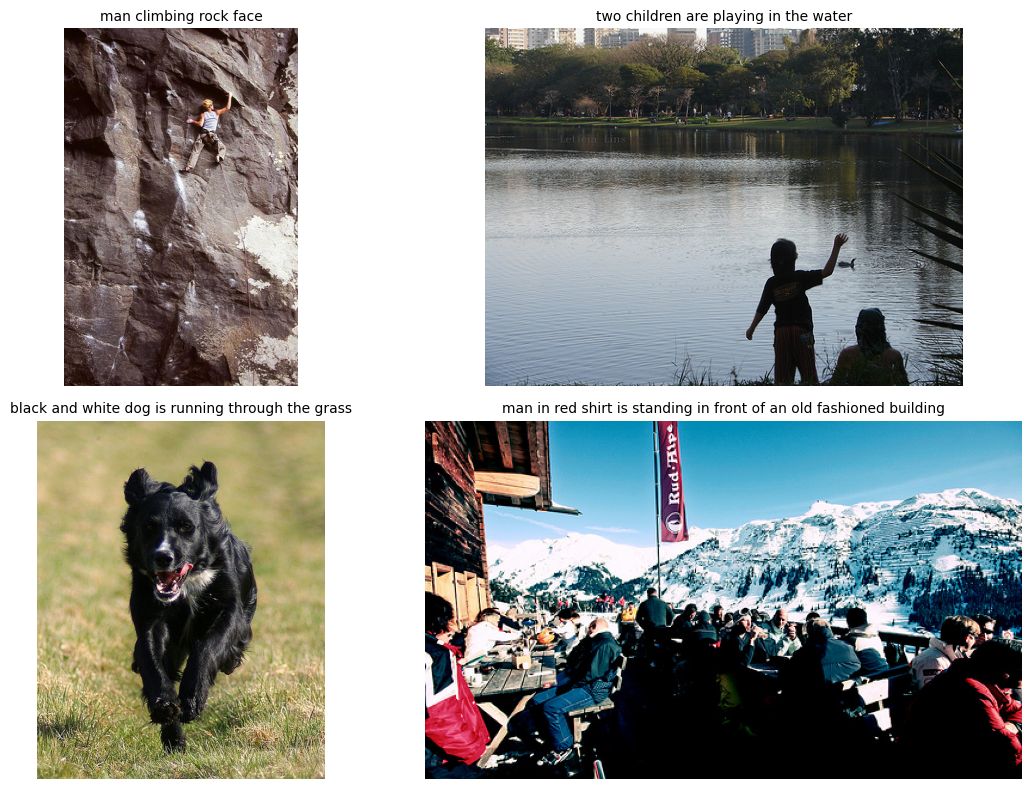

In [47]:
model_2 = load_model("../models/model_2/model_2_29.keras")

test_features = load_testing_imgs(directory="../data/raw/Flickr8k_Dataset/Flicker8k_Dataset",
                             txt_file="../data/raw/Flickr8k_text/Flickr_8k.devImages.txt")

caps = generate_captions_for_images_with_beam_search(model=model_2, 
                                                     tokenizer=tk, 
                                                     features=test_features, 
                                                     max_length=max_caps,
                                                     beam_index=3)

display_images_with_captions(
    captions_dict=caps,
    image_dir="../data/raw/testing_images"
)

## Model 3

* Adding GloVe embeddings

In [48]:
# # Downloading the pre-trained glove vectors
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip glove.6B.zip

In [49]:
GLOVE_PATH = './glove.6B.100d.txt'

embedding_index = {}
with open(GLOVE_PATH, 'r') as f:
    # each line in the glove file is structured as "word vector"
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector
        
print(f'Loaded {len(embedding_index)} word vectors from GloVe')

Loaded 400000 word vectors from GloVe


In [50]:
EMBEDDING_DIM = 100

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word, i in tk.word_index.items():
    if i < vocab_size:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector

/home/mahmoud/anaconda3/envs/tf_gpu_py311/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/home/mahmoud/anaconda3/envs/tf_gpu_py311/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 2048)      │          0 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 512)       │  1,049,088 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 34, 100)   │    757,700 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, 34)        │          0 │ input_layer_8[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 512)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 256)       │    365,568 │ embedding_2[0][0… │
│                     │                   │            │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 768)       │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    393,728 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 512)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │    131,328 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 7577)      │  1,947,289 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,644,701 (17.72 MB)

 Trainable params: 3,887,001 (14.83 MB)

 Non-trainable params: 757,700 (2.89 MB)

None


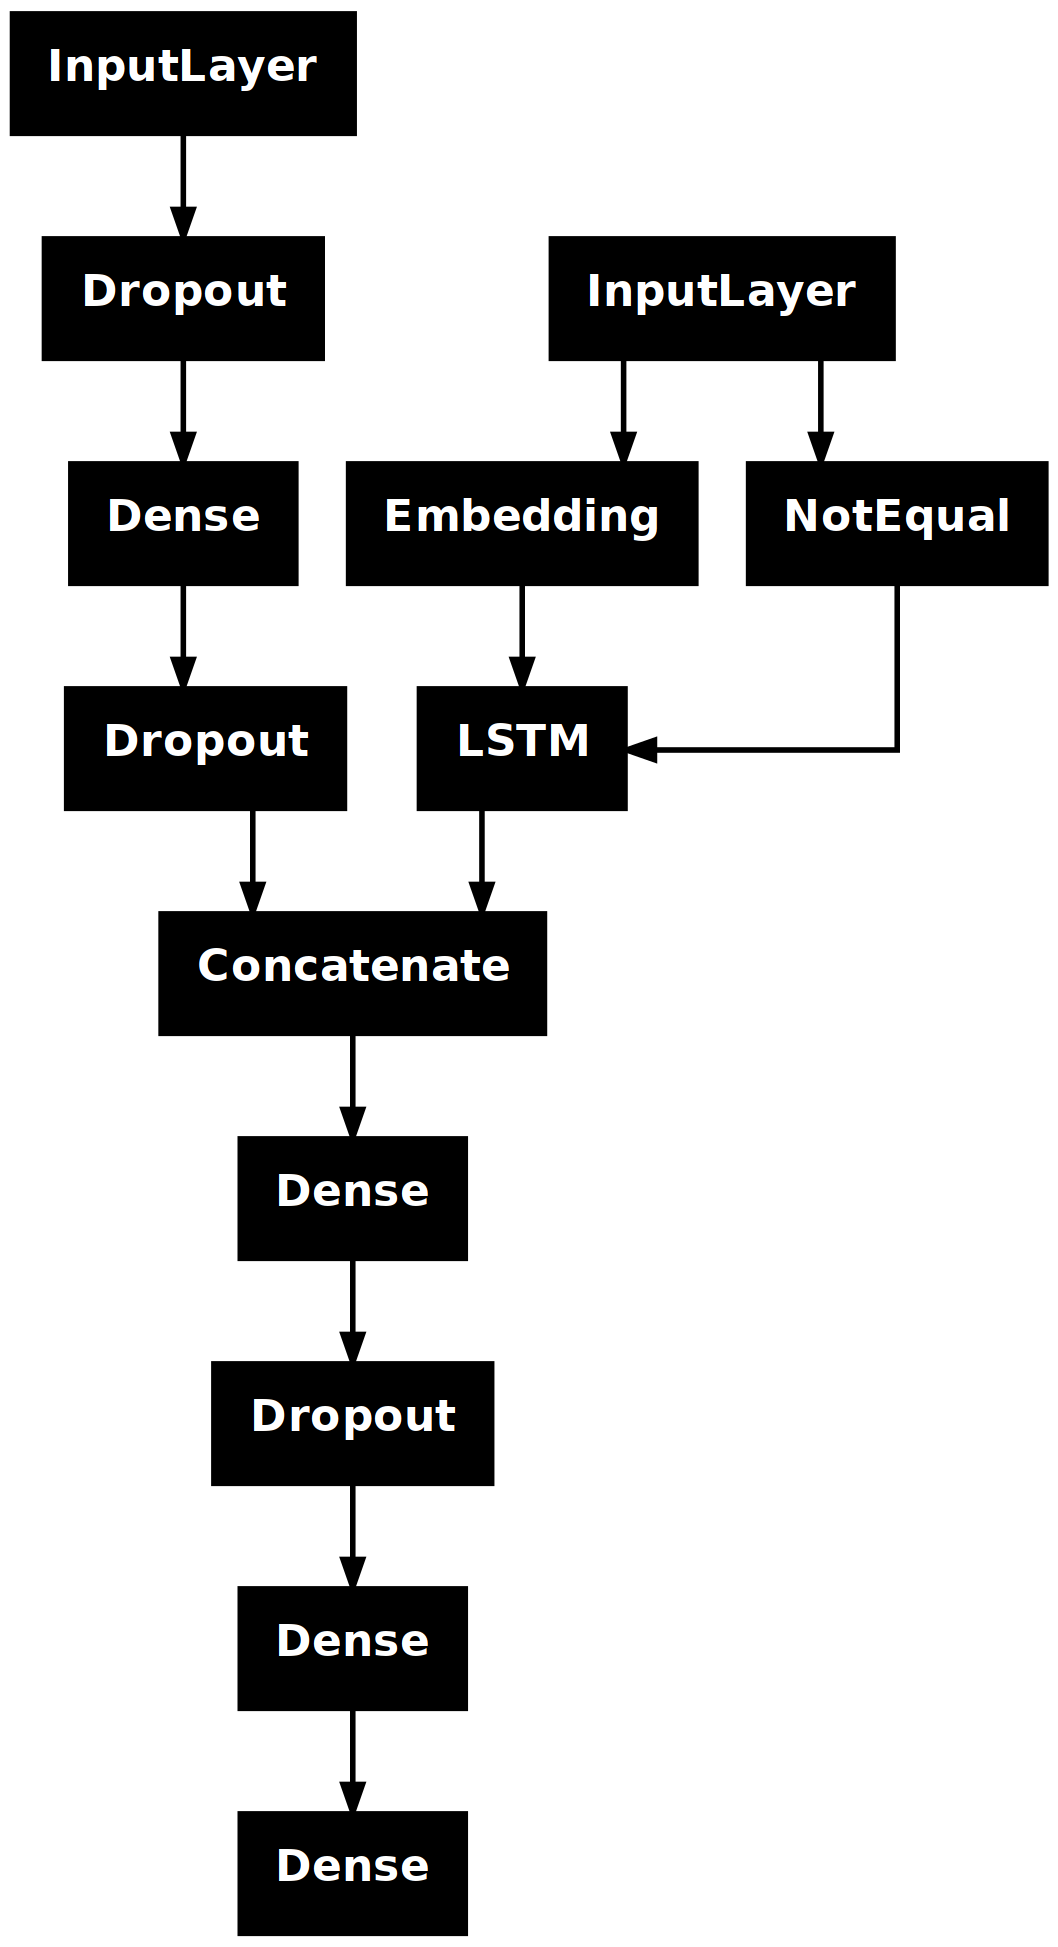

In [51]:
# CNN model inputs
img_inputs = Input(shape=(2048,))
fe1 = Dropout(0.5)(img_inputs)
fe2 = Dense(512, activation='relu')(fe1)
fe3 = Dropout(0.5)(fe2)

# LSTM model inputs
seq_inputs = Input(shape=(max_caps,))
se1 = Embedding(input_dim=vocab_size,
                output_dim=100,
                weights=embedding_matrix,
                input_length=max_caps,
                mask_zero=True,
                trainable=False)(seq_inputs)
se2 = LSTM(256)(se1)

# Adding the models
decoder1 = Concatenate()([fe3, se2])
decoder2 = Dense(512, activation='relu')(decoder1)
decoder2 = Dropout(0.5)(decoder2)
decoder3 = Dense(256, activation='relu')(decoder2)
outputs = Dense(vocab_size, activation='softmax')(decoder3)

model = Model(inputs=[img_inputs, seq_inputs], 
              outputs=outputs)

loss = CategoricalCrossentropy(label_smoothing=0.1)
optimizer = Adam(learning_rate=1e-4, decay=1e-6, clipnorm=5.0)

model.compile(loss=loss,
              optimizer=optimizer)

print(model.summary())
plot_model(model, to_file='../models/models_summary/model_3.png')

In [52]:
# # Model_3 training

# EPOCHS = 30
# STEPS = len(descriptions)

# for i in range(EPOCHS):
    
#     history_3 = model.fit(data_generator(descriptions=descriptions,
#                                         features=image_feature_vectors,
#                                         tokenizer=tk,
#                                         max_length=max_caps,
#                                         vocab_size=vocab_size),
#                                         epochs=1, 
#                                         steps_per_epoch=STEPS, 
#                                         verbose=1)
    
#     model.save("../models/model_3/model_3_" + str(i) + ".keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


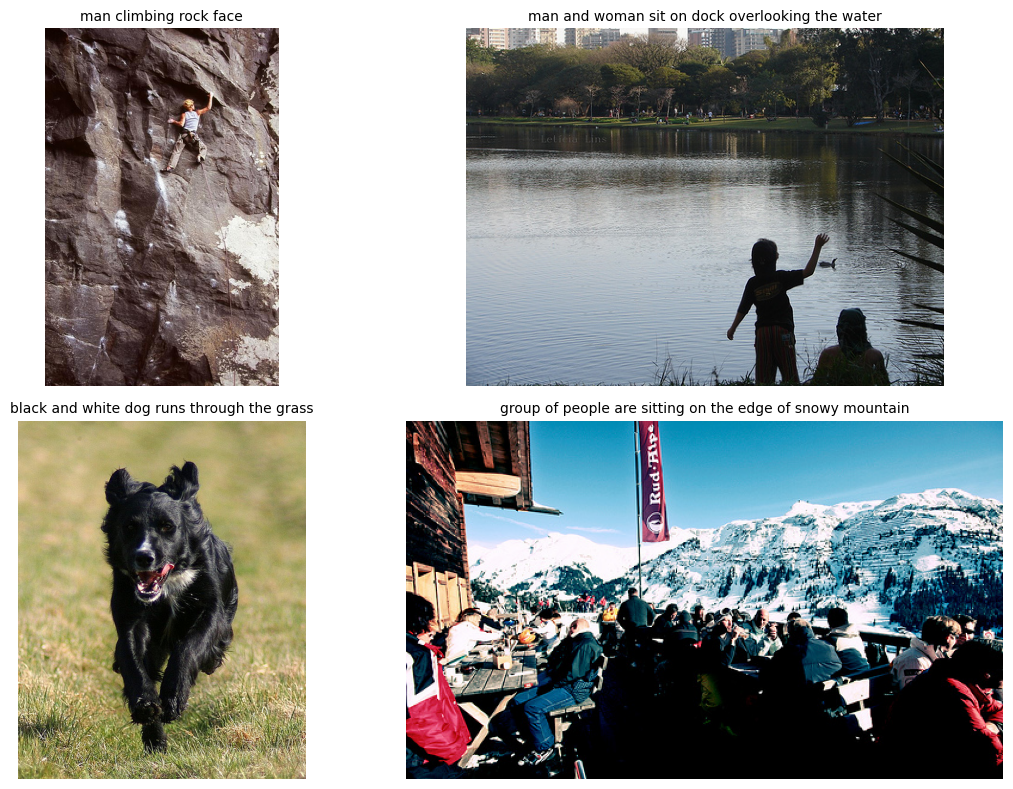

In [53]:
model_3 = load_model("../models/model_3/model_3_29.keras")

test_features = load_testing_imgs(directory="../data/raw/Flickr8k_Dataset/Flicker8k_Dataset",
                             txt_file="../data/raw/Flickr8k_text/Flickr_8k.devImages.txt")

caps = generate_captions_for_images_with_beam_search(model=model_3, 
                                                     tokenizer=tk, 
                                                     features=test_features, 
                                                     max_length=max_caps,
                                                     beam_index=3)

display_images_with_captions(
    captions_dict=caps,
    image_dir="../data/raw/testing_images"
)

### Model 4

> Since all of the previous models have been outputting similar captions which showed some bias towards certain words like 'red shirt' which appeared in a lot of the captions by all of the models even if the red color was not really present in the image, I decided to add more information and use the full capacity of the Xception model's feature extraction and will use the feature vectos in their full shape of (10, 10, 2048)

* Using model 3's structure with the GloVe embeddings
* Using the full features of the images as input (10, 10, 2048)
* Training for 200 epochs

In [54]:
full_image_feature_vectors = {img:features[img][0] for img in images} # Reshaping the vector to (10, 10, 2048) instead of (1, 10, 10, 2048)

In [55]:
features['2513260012_03d33305cf.jpg'].shape

(1, 10, 10, 2048)

/home/mahmoud/anaconda3/envs/tf_gpu_py311/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/home/mahmoud/anaconda3/envs/tf_gpu_py311/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 10, 10,    │          0 │ -                 │
│ (InputLayer)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 10, 10,    │          0 │ input_layer_10[0… │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ dropout_8[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 34, 100)   │    757,700 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 34)        │          0 │ input_layer_11[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 512)       │    262,656 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 34, 256)   │    365,568 │ embedding_3[0][0… │
│                     │                   │            │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 512)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 256)       │    525,312 │ lstm_3[0][0],     │
│                     │                   │            │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 768)       │          0 │ dropout_9[0][0],  │
│ (Concatenate)       │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 512)       │    393,728 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 512)       │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 256)       │    131,328 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 7577)      │  1,947,289 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,432,669 (20.72 MB)

 Trainable params: 4,674,969 (17.83 MB)

 Non-trainable params: 757,700 (2.89 MB)

None


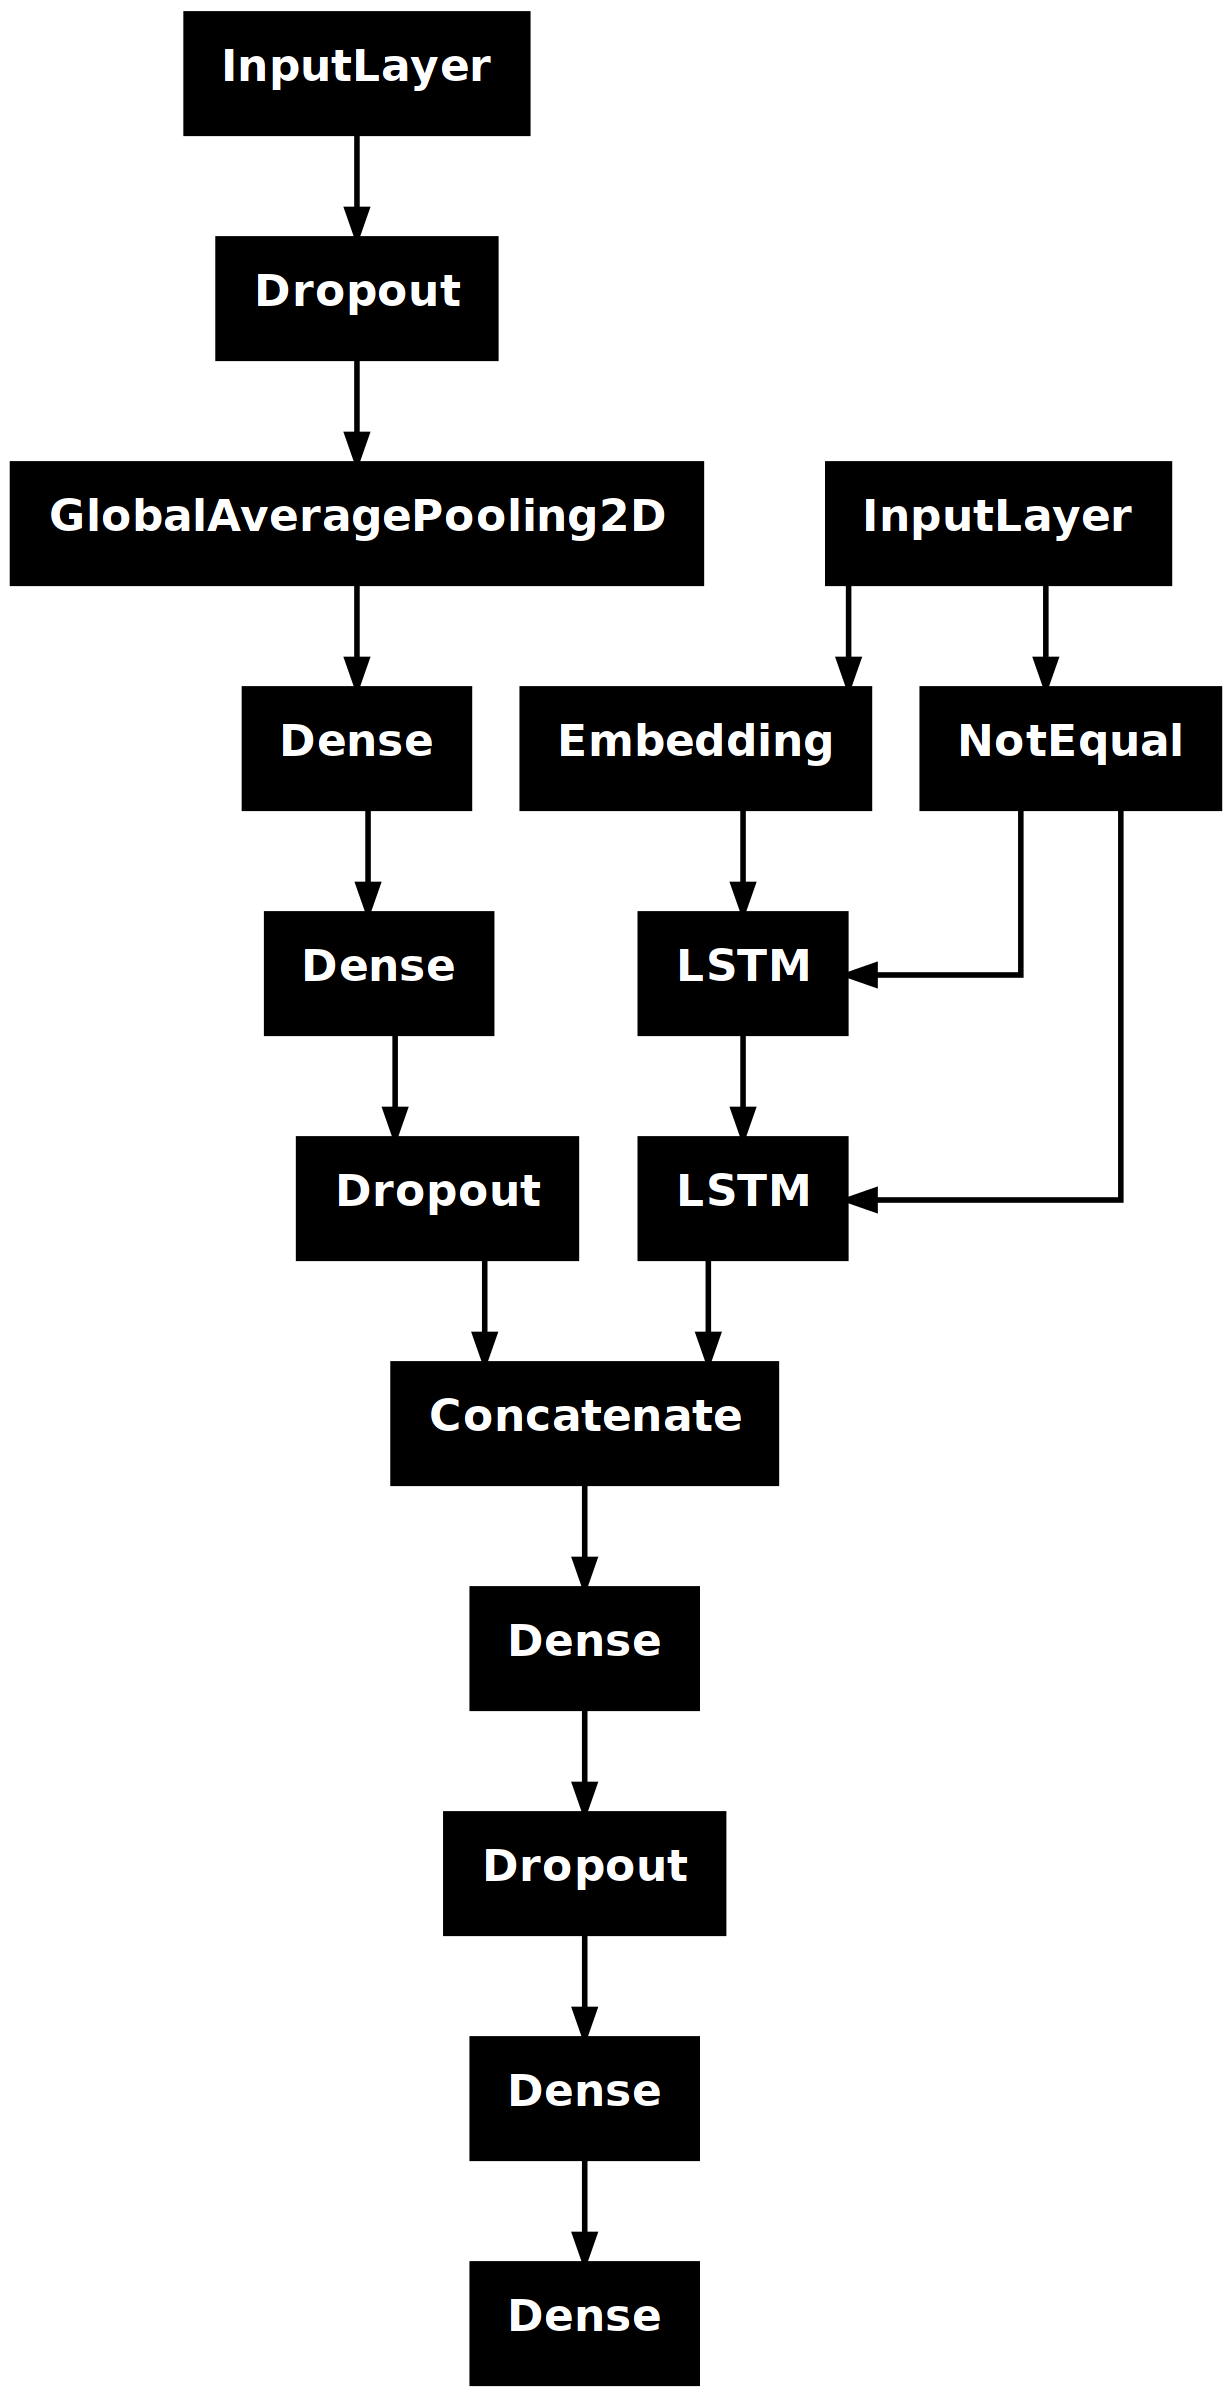

In [56]:
# CNN model inputs
img_inputs = Input(shape=(10, 10, 2048))
fe1 = Dropout(0.2)(img_inputs)
fe2 = GlobalAveragePooling2D()(fe1)
fe3 = Dense(512, activation='relu')(fe2)
fe4 = Dense(512, activation='relu')(fe3)
fe5 = Dropout(0.2)(fe4)

# LSTM model inputs
seq_inputs = Input(shape=(max_caps,))
se1 = Embedding(input_dim=vocab_size,
output_dim=100,
weights=embedding_matrix,
input_length=max_caps,
mask_zero=True,
trainable=False)(seq_inputs)
se2 = LSTM(256, return_sequences=True)(se1)
se3 = LSTM(256)(se2)

# Adding the models
decoder1 = Concatenate()([fe5, se3])
decoder2 = Dense(512, activation='relu')(decoder1)
decoder2 = Dropout(0.2)(decoder2)
decoder3 = Dense(256, activation='relu')(decoder2)
outputs = Dense(vocab_size, activation='softmax')(decoder3)

model = Model(inputs=[img_inputs, seq_inputs], 
outputs=outputs)

loss = CategoricalCrossentropy(label_smoothing=0.1)
optimizer = Adam(learning_rate=1e-4, decay=1e-6, clipnorm=5.0)

model.compile(loss=loss,
optimizer=optimizer)

print(model.summary())

plot_model(model, to_file='../models/models_summary/model_4.png')


In [57]:
# # Model_4 training

# EPOCHS = 200
# STEPS = len(descriptions)

# # global_epoch = 0

# # def scheduler(epoch, lr):
    
# #     global global_epoch
# #     # use global_epoch instead of resetting
# #     if global_epoch > 0 and global_epoch % 25 == 0:
        
# #         lr = lr * 0.1
# #         print(f"Epoch {global_epoch+1}: setting learning rate to {lr:.6f}")
        
# #     global_epoch += 1
# #     return lr

# # lr_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=0)

# train_gen = data_generator(descriptions=descriptions,
#                            features=full_image_feature_vectors,
#                            tokenizer=tk,
#                            max_length=max_caps,
#                            vocab_size=vocab_size,
#                            use_batch=True)

# # Keeping track of the best loss and model number pair
# best_loss_model = [10, 0]
# previous_loss = 10

# for i in range(EPOCHS):
    
#     history_4 = model.fit(train_gen,
#                 epochs=1, 
#                 steps_per_epoch=STEPS, 
#                 verbose=1)
    
#     curr_loss = history_4.history["loss"][0]
    
#     if curr_loss < best_loss_model[0]:
        
#         best_loss_model = [curr_loss, i]
    
#     # Stopping condition, if there is no major improvements between models 
#     if -0.00005 < curr_loss - previous_loss < 0.00005:
        
#         model.save("../models/model_4/model_4_" + str(i) + ".keras")
#         break

#     else: 
        
#         previous_loss = curr_loss
    
#         model.save("../models/model_4/model_4_" + str(i) + ".keras")


In [59]:
# curr_loss, best_loss_model[1]

Throughout training, the model that had the best loss score was model_199 with a loss of `2.126386880874634`

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


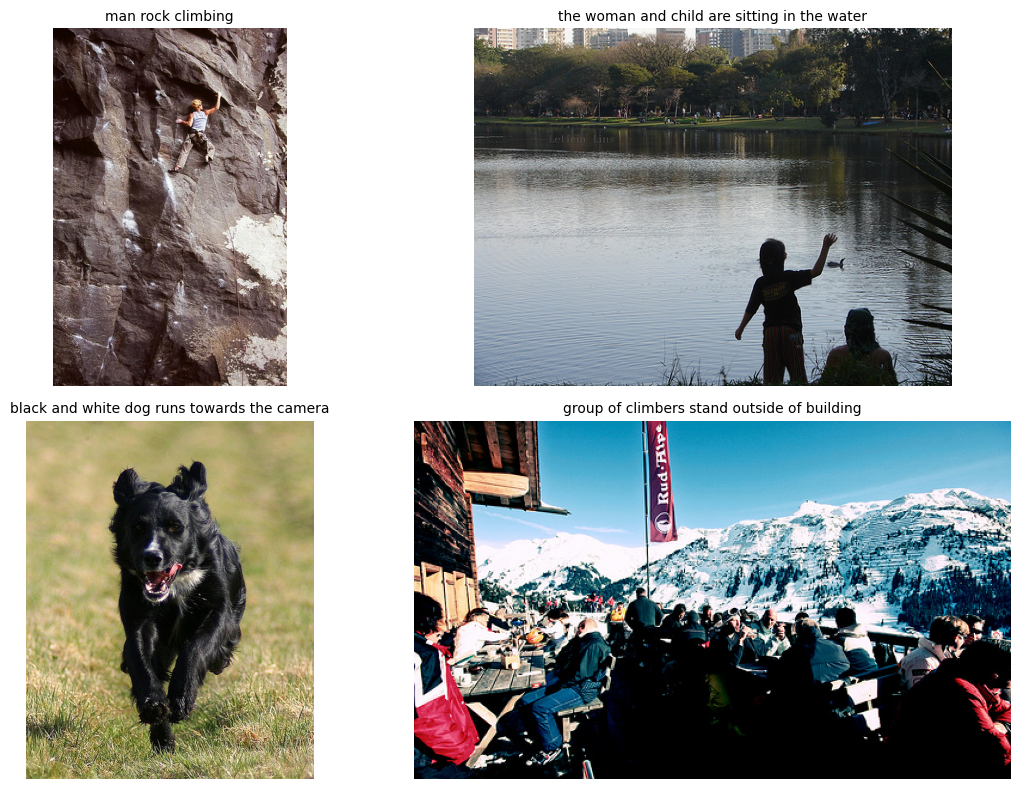

In [60]:
model_5 = load_model("../models/model_4/model_4_199.keras")

test_features = load_testing_imgs(directory="../data/raw/Flickr8k_Dataset/Flicker8k_Dataset",
txt_file="../data/raw/Flickr8k_text/Flickr_8k.devImages.txt",
full_vector=True)

caps = generate_captions_for_images_with_beam_search(model=model_5, 
                                                     tokenizer=tk, 
                                                     features=test_features, 
                                                     max_length=max_caps,
                                                     beam_index=5)

display_images_with_captions(
    captions_dict=caps,
    image_dir="../data/raw/testing_images"
)
